<div style="background-image: linear-gradient(to right, #00C9FF 0%, #92FE9D 100%); padding: 15px; border-radius: 10px; box-shadow: 3px 3px 8px rgba(0,0,0,0.2);">
  <h2 style="color: #2C3E50; font-family: 'Trebuchet MS', sans-serif; margin: 0; font-weight: bold;"> 📥 Step 1: Library Imports and Data Loading </h2>
</div>

In [4]:
# Importing all required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix

# Loading  the dataset
df = pd.read_csv('data.csv')
print("Data successfully loaded!")

Data successfully loaded!


<div style="background-image: linear-gradient(to right, #FDFC47 0%, #24FE41 100%); padding: 15px; border-radius: 10px; box-shadow: 3px 3px 8px rgba(0,0,0,0.2); margin-top: 10px;">
  <h2 style="color: #2C3E50; font-family: 'Trebuchet MS', sans-serif; margin: 0; font-weight: bold;"> 🔍 Step 2: Exploratory Data Analysis (EDA) </h2>
</div>

Dataset Shape: 171 rows (molecules) and 1204 columns (features).
Total Missing Values: 0

Class Distribution (Raw):
Class
NonToxic    115
Toxic        56
Name: count, dtype: int64


/tmp/ipykernel_201/462772360.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Class', palette='Set2')


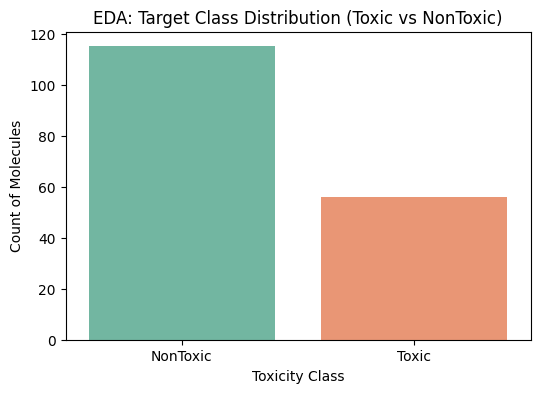

In [5]:
# 1. Check the shape of the data
print(f"Dataset Shape: {df.shape[0]} rows (molecules) and {df.shape[1]} columns (features).")

# 2. Check for missing values
total_missing = df.isnull().sum().sum()
print(f"Total Missing Values: {total_missing}")

# 3. Check Target Class Distribution
print("\nClass Distribution (Raw):")
print(df['Class'].value_counts())

# 4. Visualize the Class Imbalance
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Class', palette='Set2')
plt.title('EDA: Target Class Distribution (Toxic vs NonToxic)')
plt.ylabel('Count of Molecules')
plt.xlabel('Toxicity Class')
plt.show()

<div style="background-image: linear-gradient(to right, #FF758C 0%, #FF7EB3 100%); padding: 15px; border-radius: 10px; box-shadow: 3px 3px 8px rgba(0,0,0,0.2); margin-top: 10px;">
  <h2 style="color: white; font-family: 'Trebuchet MS', sans-serif; margin: 0; font-weight: bold;"> 🛠️ Step 3: Data Preprocessing </h2>
</div>

In [9]:
# 1. Separate Features (X) and Target (y)
X = df.drop('Class', axis=1)
y_raw = df['Class']

# 2. Encode the Target
encoder = LabelEncoder()
y = encoder.fit_transform(y_raw)
print(f"Classes encoded successfully: {encoder.classes_} -> [0, 1]")

# 3. Train-Test Split (20% of data for final testing)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Training Data: {X_train.shape[0]} molecules.")
print(f"Testing Data: {X_test.shape[0]} molecules.")

Classes encoded successfully: ['NonToxic' 'Toxic'] -> [0, 1]
Training Data: 136 molecules.
Testing Data: 35 molecules.


<div style="background-image: linear-gradient(to right, #8E2DE2 0%, #4A00E0 100%); padding: 15px; border-radius: 10px; box-shadow: 3px 3px 8px rgba(0,0,0,0.2); margin-top: 10px;">
  <h2 style="color: white; font-family: 'Trebuchet MS', sans-serif; margin: 0; font-weight: bold;"> 🧠 Step 4: Feature Selection, Cross-Validation, & Random Forest </h2>
</div>

In [10]:
# 1. Build a Leakage-Free Pipeline
# This mathematically ensures Scaling and Feature Selection only happen on training folds!
pipeline = Pipeline([
    ('scaler', StandardScaler()),                        # Preprocessing: Scale features
    ('selector', SelectKBest(score_func=f_classif)),     # Feature Selection: ANOVA F-test
    ('rf', RandomForestClassifier(class_weight='balanced', random_state=42)) # Base Model
])

# 2. Define the hyperparameters to test
param_grid = {
    'selector__k': [15, 20, 30],         # Test keeping the top 15, 20, or 30 features
    'rf__n_estimators': [100, 300],      # Test 100 vs 300 decision trees
    'rf__max_depth': [5, 10, None]       # Limit tree depth to prevent overfitting
}

# 3. Set up 5-Fold Stratified Cross-Validation
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 4. Run GridSearchCV to find the best model via Cross-Validation
print("Running 5-Fold Cross-Validation and Hyperparameter Tuning...")
grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=cv_strategy,
    scoring='balanced_accuracy',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print(f"\nBest Model Parameters Found:\n{grid_search.best_params_}")
print(f"Best CV Balanced Accuracy: {grid_search.best_score_ * 100:.2f}%")

Running 5-Fold Cross-Validation and Hyperparameter Tuning...


/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:111: UserWarning: Features [ 203  214  253  378  702  759  989 1028 1035 1110] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:112: RuntimeWarning: invalid value encountered in divide
  f = msb / msw



Best Model Parameters Found:
{'rf__max_depth': 10, 'rf__n_estimators': 300, 'selector__k': 15}
Best CV Balanced Accuracy: 47.25%


<div style="background-image: linear-gradient(to right, #FC466B 0%, #3F5EFB 100%); padding: 15px; border-radius: 10px; box-shadow: 3px 3px 8px rgba(0,0,0,0.2); margin-top: 10px;">
  <h2 style="color: white; font-family: 'Trebuchet MS', sans-serif; margin: 0; font-weight: bold;"> 📊 Step 5: Final Evaluation on Test Set </h2>
</div>

----- FINAL CLASSIFICATION REPORT -----
              precision    recall  f1-score   support

    NonToxic       0.67      0.83      0.74        24
       Toxic       0.20      0.09      0.12        11

    accuracy                           0.60        35
   macro avg       0.43      0.46      0.43        35
weighted avg       0.52      0.60      0.55        35



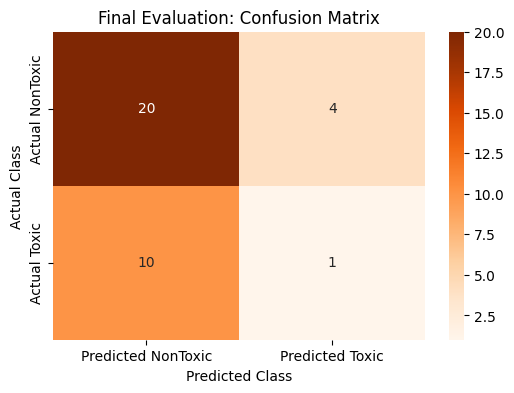

In [11]:
# 1. Extract the absolute best model from the GridSearch Cross-Validation
best_model = grid_search.best_estimator_

# 2. Make predictions on the hidden 20% test set
final_predictions = best_model.predict(X_test)

# 3. Print the Classification Report
print("----- FINAL CLASSIFICATION REPORT -----")
print(classification_report(y_test, final_predictions, target_names=['NonToxic', 'Toxic']))

# 4. Plot the Confusion Matrix
cm = confusion_matrix(y_test, final_predictions)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Predicted NonToxic', 'Predicted Toxic'],
            yticklabels=['Actual NonToxic', 'Actual Toxic'])
plt.title('Final Evaluation: Confusion Matrix')
plt.ylabel('Actual Class')
plt.xlabel('Predicted Class')
plt.show()